# Hidden-state similarity vs. observations / reward

Loads trajectories saved by `train_treadmill_agent_jax_reward_gated_logits_hidden_credit.py` and, for a
chosen time window, plots:

- **top:** the raw observation channels + reward (per-row normalized heatmap, time on x);
- **bottom:** the **hidden-state similarity matrix used in the credit calculation**. In `credit_scan`
  each critic hidden state is L2-normalized (`h / ||h||`) before it is written into the eligibility
  trace and read back out, so the relevant similarity between two moments `i, j` is the dot product
  `h_i . h_j` of the unit-normalized hidden states = **cosine similarity**. Entry `(i, j)` of the
  matrix is that value, so you can see how similar the hidden activity is at different moments in time.

Two trajectories are available under `persistence_gated_exp_gru_initial_prob_offset_full_pred_r_hidden`:
`traj_000040.pkl` and `traj_000060.pkl` (each a list of 15 envs).

In [19]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Locate the repo root (the directory that contains results/).
REPO = Path.cwd()
while not (REPO / 'results').exists() and REPO != REPO.parent:
    REPO = REPO.parent

EXP = 'persistence_gated_exp_gru_initial_prob_offset_full_pred_r_hidden'
TRAJ_DIR = REPO / 'results' / EXP / 'trajectories'
TRAJ_FILES = {40: TRAJ_DIR / 'traj_000040.pkl', 60: TRAJ_DIR / 'traj_000060.pkl'}

print('repo:', REPO)
for k, p in TRAJ_FILES.items():
    print(f'  traj {k}: {p}  (exists: {p.exists()})')

repo: /home/david.bell/work/favorably_connected_2
  traj 40: /home/david.bell/work/favorably_connected_2/results/persistence_gated_exp_gru_initial_prob_offset_full_pred_r_hidden/trajectories/traj_000040.pkl  (exists: True)
  traj 60: /home/david.bell/work/favorably_connected_2/results/persistence_gated_exp_gru_initial_prob_offset_full_pred_r_hidden/trajectories/traj_000060.pkl  (exists: False)


In [20]:
def load_env(traj_file, env_idx=0):
    """Arrays for one saved env. `observations` is [obs(obs_size), action_onehot(2), prev_reward(1)],
    so obs_size = width - 3. Returns the observation channels, reward, action, and both hidden states."""
    with open(traj_file, 'rb') as f:
        envs = pickle.load(f)
    d = envs[env_idx]
    obs_full = np.asarray(d['observations'])              # (T, obs_size + 3)
    obs_size = obs_full.shape[1] - 3
    return {
        'obs': obs_full[:, :obs_size],                    # (T, obs_size)
        'rewards': np.asarray(d['rewards']),              # (T,)
        'actions': np.asarray(d['actions']),              # (T,)  action taken each step
        'actor_hidden': np.asarray(d['actor_hidden']),    # (T, hidden)
        'critic_hidden': np.asarray(d['critic_hidden']),  # (T, hidden)  <- used by the credit calc
        'obs_size': obs_size,
        'n_envs': len(envs),
        'T': obs_full.shape[0],
    }

In [21]:
def plot_obs_and_similarity(traj_file, env_idx=0, t0=0, win=1000, hidden_key='critic_hidden',
                            vmin=-1.0, vmax=1.0, cmap='RdBu_r', figsize=(6, 6.5)):
    """Top: raw obs channels + reward + action over [t0, t0+win). Bottom: the cosine-similarity
    matrix of the L2-normalized hidden states over the same window -- exactly the similarity used in
    credit_scan (h is normalized to unit length there before the outer-product / read-out)."""
    e = load_env(traj_file, env_idx)
    t1 = min(t0 + win, e['T'])
    obs = e['obs'][t0:t1]                                  # (win, obs_size)
    reward = e['rewards'][t0:t1]                           # (win,)
    action = e['actions'][t0:t1]                           # (win,)
    H = e[hidden_key][t0:t1]                               # (win, hidden)

    # unit-normalize each hidden state (matches h_t / sqrt(sum(h_t**2)) in credit_scan), then Gram.
    Hn = H / (np.linalg.norm(H, axis=1, keepdims=True) + 1e-6)
    S = Hn @ Hn.T                                          # (win, win) cosine similarity

    # top panel: (obs channels + reward + action) x time.
    rows = np.concatenate([obs.T, reward[None, :], action[None, :]], axis=0)   # (obs_size + 2, win)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 5])
    ax_top = fig.add_subplot(gs[0])
    ax_mat = fig.add_subplot(gs[1], sharex=ax_top)

    ax_top.imshow(rows, extent=[t0, t1, rows.shape[0], 0], aspect='auto',
                  cmap='viridis', interpolation='nearest')
    ax_top.set_yticks(np.arange(rows.shape[0]) + 0.5)
    ax_top.set_yticklabels([f'obs[{c}]' for c in range(e['obs_size'])] + ['reward', 'action'], fontsize=7)
    ax_top.tick_params(labelbottom=False)
    ax_top.set_title(f'{Path(traj_file).name}  env {env_idx}  |  t in [{t0}, {t1})  |  '
                     f'{hidden_key} cosine similarity', fontsize=9)

    im = ax_mat.imshow(S, extent=[t0, t1, t1, t0], cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='auto', interpolation='nearest')
    ax_mat.set_xlabel('time step'); ax_mat.set_ylabel('time step')
    cb = fig.colorbar(im, ax=ax_mat, fraction=0.046, pad=0.02)
    cb.set_label('cosine similarity  (h_i . h_j,  |h| = 1)')
    return fig, S

## Trajectory `traj_000040` (env 0)

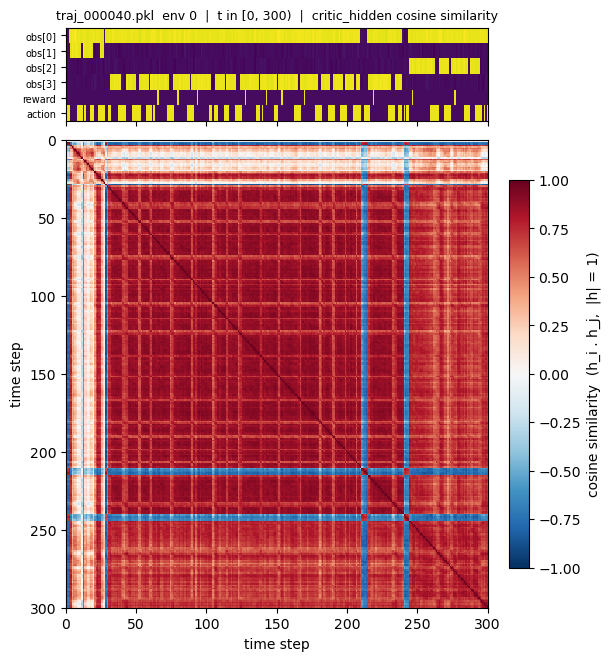

In [22]:
_ = plot_obs_and_similarity(TRAJ_FILES[40], env_idx=0, t0=0, win=300)

## Trajectory `traj_000060` (env 0)

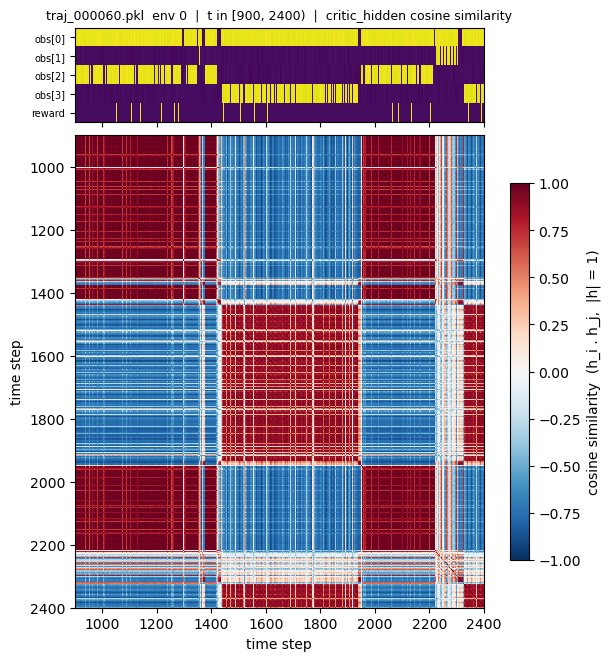

In [16]:
_ = plot_obs_and_similarity(TRAJ_FILES[60], env_idx=0, t0=900, win=1500)

### Notes / knobs
- `hidden_key='actor_hidden'` compares the actor hidden state instead (the credit calc uses
  `critic_hidden`).
- `t0` / `win` pick the window; a 20000-step trajectory can't be shown whole (the matrix is
  `win x win`), so scan windows of a few hundred to ~1500 steps.
- `env_idx` selects among the 15 saved envs; `vmin`/`vmax` set the similarity color limits.